In [50]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [51]:
torch.manual_seed(1234)
np.random.seed(1234)
torch.set_default_dtype(torch.float32)

v = 1  #Størrelse relevant for diff-ligningen 
c = 1
Y = 2*torch.pi
T = 3 
K = 3
N_f = 2000
adam_epochs = 10000
adam_lr = 1e-3
refine_every = 400
n_candidates = 8000
replace_fraction = 0.2

lbfgs_max_iter = 600
lambda_load = 1e-2

In [52]:
class Sin(nn.Module):
    def forward(self, x):
        return torch.sin(x)


class FeatureMap2D(nn.Module):
    def __init__(self, Y, T, n_freq_y=8, n_freq_t=8):
        super().__init__()
        self.Y = Y
        self.T = T

        ky = torch.arange(1, n_freq_y + 1, dtype=torch.float32).view(1, -1)
        kt = torch.arange(1, n_freq_t + 1, dtype=torch.float32).view(1, -1)

        self.register_buffer("ky", ky)
        self.register_buffer("kt", kt)

    def forward(self, y, t):
        # y, t : [N,1]
        y_scaled = 2.0 * y / self.Y - 1.0
        t_scaled = 2.0 * t / self.T - 1.0

        zy = math.pi * y_scaled * self.ky   # [N, n_freq_y]
        zt = math.pi * t_scaled * self.kt   # [N, n_freq_t]

        feats = torch.cat([
            y_scaled,
            t_scaled,
            torch.sin(zy),
            torch.cos(zy),
            torch.sin(zt),
            torch.cos(zt)
        ], dim=1)

        return feats
    
def pde_residual(model, y, t, c, v):
    y = y.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)
    zero = torch.zeros_like(t)
    gates, expert_vals, u = model(y, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),create_graph=True)[0]

    r = u_t + c * u_y - v * u_yy
    Gk0, experts0, ini_pred = model(y,zero)
    return u, u_y, u_t, u_yy, r, gates, expert_vals, ini_pred


@torch.no_grad()
def adaptive_refine(model, yt_old, Y, T, c, v,
                    n_candidates=8000, replace_fraction=0.2, gamma=50.0, device="cpu"):

    n_old = yt_old.shape[0]
    n_replace = max(1, int(replace_fraction * n_old))
    n_keep = n_old - n_replace

    y_cand = Y * torch.rand(n_candidates, 1, device=device)
    t_cand = T * torch.rand(n_candidates, 1, device=device)

    with torch.enable_grad():
        _, _, _, _, r, _, _, _ = pde_residual(model, y_cand, t_cand, c, v)
        r2 = (r.detach().squeeze())**2

    med = torch.median(r2)
    if med.item() > 0:
        r2 = torch.clamp(r2, min=med.item(), max=(gamma * med).item())
    else:
        r2 = r2 + 1e-12

    probs = r2 / torch.sum(r2)
    idx_new = torch.multinomial(probs, num_samples=n_replace, replacement=False)

    yt_hard = torch.cat([y_cand[idx_new], t_cand[idx_new]], dim=1).detach()

    perm = torch.randperm(n_old, device=device)
    yt_keep = yt_old[perm[:n_keep]].detach()

    yt_new = torch.cat([yt_keep, yt_hard], dim=0)
    yt_new = yt_new[torch.randperm(yt_new.shape[0], device=device)]

    return yt_new

class SoftAdapt:
    def __init__(self, loss_names, base_weights=None, beta=5.0, eps=1e-8, enabled=True):

        self.loss_names = loss_names
        self.beta = beta
        self.eps = eps
        self.enabled = enabled

        if base_weights is None:
            base_weights = {name: 1.0 for name in loss_names}

        self.base_weights = base_weights
        self.prev_losses = None

        self.current_weights = {
            name: float(base_weights[name]) for name in loss_names
        }

    def __call__(self, losses, update=True):

        # Hvis SoftAdapt er slået fra, returneres de faste vægte
        if not self.enabled:
            return {
                name: torch.tensor(
                    self.base_weights[name],
                    device=losses[name].device,
                    dtype=losses[name].dtype
                )
                for name in self.loss_names
            }

        # Første gang har vi ingen tidligere losses at sammenligne med
        if self.prev_losses is None:
            self.prev_losses = {
                name: losses[name].detach().clone()
                for name in self.loss_names
            }

            return {
                name: torch.tensor(
                    self.base_weights[name],
                    device=losses[name].device,
                    dtype=losses[name].dtype
                )
                for name in self.loss_names
            }

        # Hvis update=False, bruges de gemte vægte bare igen
        if not update:
            return {
                name: torch.tensor(
                    self.current_weights[name],
                    device=losses[name].device,
                    dtype=losses[name].dtype
                )
                for name in self.loss_names
            }

        # Beregn relativ ændring:
        # Hvis loss_i / previous_loss_i er stor, betyder det,
        # at det loss-led ikke falder så godt.
        ratios = []
        for name in self.loss_names:
            ratio = losses[name].detach() / (self.prev_losses[name] + self.eps)
            ratios.append(ratio)

        ratios = torch.stack(ratios)

        # Numerisk stabilisering
        ratios = ratios - torch.max(ratios)

        # SoftAdapt-vægte
        adaptive_factors = len(self.loss_names) * torch.softmax(self.beta * ratios, dim=0)

        weights = {}
        for i, name in enumerate(self.loss_names):
            weights[name] = self.base_weights[name] * adaptive_factors[i]

        # Gem vægtene som almindelige floats til senere brug
        self.current_weights = {
            name: float(weights[name].detach().cpu())
            for name in self.loss_names
        }

        # Opdater tidligere losses
        self.prev_losses = {
            name: losses[name].detach().clone()
            for name in self.loss_names
        }

        return weights

def compute_loss(model, y_batch, t_batch, c, v, lambda_load, K):
    u, u_y, u_t, u_yy, r, gates, expert_vals, ini_pred = pde_residual(model, y_batch, t_batch, c, v)

    loss_pde = torch.mean(r**2)
    loss_ini = torch.mean((torch.sin(y_batch) - ini_pred)**2)
    gbar = torch.mean(gates, dim=0)          
    loss_load = K * torch.sum(gbar**2)
    loss_total = loss_pde + lambda_load * loss_load + 10*loss_ini
    return loss_total, loss_pde, loss_load, u, gates, loss_ini

In [53]:
exp1 = nn.Sequential(nn.Linear(22,10), nn.Tanh(), nn.Linear(10,10), nn.Tanh(), nn.Linear(10, 12), nn.Tanh(), nn.Linear(12,10), nn.Tanh(), nn.Linear(10,1))
exp2 = nn.Sequential(nn.Linear(22,10), Sin(), nn.Linear(10,10), Sin(), nn.Linear(10, 12), Sin(), nn.Linear(12,10), Sin(), nn.Linear(10,1))
exp3 = nn.Sequential(nn.Linear(22,10), nn.Tanh(), nn.Linear(10,10), nn.Tanh(), nn.Linear(10, 12), nn.Tanh(), nn.Linear(12,10), nn.Tanh(), nn.Linear(10,1)) 
gating_model = nn.Sequential(nn.Linear(22,10), nn.Tanh(), nn.Linear(10,10), nn.Tanh(), nn.Linear(10, 12), nn.Tanh(), nn.Linear(12,10), nn.Tanh(), nn.Linear(10,3)) 

In [54]:
def MoE(y,t):
    tauy = (2.0 * y /Y) - 1.0
    taut = (2.0 * t /T) - 1.0
    k = torch.arange(1, 6, dtype=torch.float32).view(1, -1)
    zy = math.pi * tauy * k
    zt = math.pi * taut * k
    feature_map = FeatureMap2D(Y=Y, T=T, n_freq_y=5, n_freq_t=5).to(device)
    y_t_scaled = feature_map(y,t)
    logits = gating_model(y_t_scaled)
    Gk = torch.softmax(logits, dim=1)
    Gk_bar = torch.sum(Gk, dim=0) / (len(y)*len(t))

    out1, out2, out3 = exp1(y_t_scaled), exp2(y_t_scaled), exp3(y_t_scaled)
    experts = torch.stack([out1.squeeze(), out2.squeeze(), out3.squeeze()], dim=1)
    u = torch.sum(Gk * experts, dim=1, keepdim=True) 
    return Gk, experts, u

t_f = torch.rand(N_f, 1, device=device)
y_f = Y * torch.rand(N_f, 1, device=device)



optimizer = torch.optim.Adam(list(gating_model.parameters()) + list(exp1.parameters()) + list(exp2.parameters())+list(exp3.parameters()), lr=adam_lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2500, gamma=0.5)

hist_total = []
hist_ode = []
hist_load = []

for epoch in range(1, adam_epochs + 1):
    loss_total, loss_ode, loss_load, _, _, loss_ini = compute_loss(MoE, y_f, t_f, c,v,lambda_load, K)

    optimizer.zero_grad()
    loss_total.backward()
    torch.nn.utils.clip_grad_norm_(list(gating_model.parameters()) + list(exp1.parameters()) + list(exp2.parameters())+list(exp3.parameters()), 1.0)
    optimizer.step()
    scheduler.step()

    hist_total.append(loss_total.item())
    hist_ode.append(loss_ode.item())
    hist_load.append(loss_load.item())

    if epoch % refine_every == 0:
        yt_f = adaptive_refine(
            model=MoE,
            yt_old=torch.cat([y_f, t_f], dim=1),
            Y = Y,
            T = T, 
            c = c, 
            v = v, 
            n_candidates=n_candidates,
            replace_fraction=replace_fraction,
            gamma=50.0
        )

        y_f = yt_f[:, 0:1]
        t_f = yt_f[:, 1:2]

    if epoch % 500 == 0:
        print(
            f"Adam epoch {epoch:5d} | "
            f"total={loss_total.item():.6e} | "
            f"ode={loss_ode.item():.6e} | "
            f"load={loss_load.item():.6e}"
        )


lbfgs = torch.optim.LBFGS(
    list(gating_model.parameters()) + list(exp1.parameters()) + list(exp2.parameters())+list(exp3.parameters()),
    lr=1.0,
    max_iter=lbfgs_max_iter,
    max_eval=lbfgs_max_iter,
    history_size=50,
    line_search_fn="strong_wolfe"
)

def closure():
    lbfgs.zero_grad()
    loss_total, loss_ode, loss_load, _, _, loss_ini= compute_loss(MoE, y_f, t_f, c,v,lambda_load, K)
    loss_total.backward()
    return loss_total

print("\nStarting L-BFGS...")
final_lbfgs_loss = lbfgs.step(closure)
print(f"Final L-BFGS loss = {final_lbfgs_loss.item():.6e}")



t_plot = torch.linspace(0.0, T, 2000, device=device).reshape(-1, 1)

with torch.enable_grad():
    x_plot, x_t_plot, x_tt_plot, r_plot, gates_plot, expert_vals_plot = pde_residual(MoE, t_plot)

t_np = t_plot.detach().cpu().numpy()
x_np = x_plot.detach().cpu().numpy()
r_np = r_plot.detach().cpu().numpy()
gates_np = gates_plot.detach().cpu().numpy()

# exact solution
x_exact = np.exp(-v*t_np)*np.sin(x_np - c*t_np)

max_err = np.max(np.abs(x_np - x_exact))
l2_rel = np.linalg.norm(x_np - x_exact) / np.linalg.norm(x_exact)

print(f"Max abs error = {max_err:.6e}")
print(f"Relative L2   = {l2_rel:.6e}")


Adam epoch   500 | total=3.148134e-02 | ode=1.942966e-02 | load=1.073388e+00
Adam epoch  1000 | total=1.238436e-02 | ode=1.948483e-03 | load=1.021492e+00
Adam epoch  1500 | total=1.086220e-02 | ode=6.076386e-04 | load=1.005020e+00
Adam epoch  2000 | total=1.032883e-02 | ode=2.660386e-04 | load=1.001788e+00
Adam epoch  2500 | total=1.041220e-02 | ode=2.514856e-04 | load=1.002532e+00
Adam epoch  3000 | total=1.019376e-02 | ode=1.512987e-04 | load=1.001943e+00
Adam epoch  3500 | total=1.014378e-02 | ode=1.142322e-04 | load=1.000770e+00
Adam epoch  4000 | total=1.023517e-02 | ode=1.088269e-04 | load=1.000331e+00
Adam epoch  4500 | total=1.009404e-02 | ode=7.566078e-05 | load=1.000179e+00
Adam epoch  5000 | total=1.008052e-02 | ode=6.439215e-05 | load=1.000088e+00
Adam epoch  5500 | total=1.007196e-02 | ode=5.740387e-05 | load=1.000078e+00
Adam epoch  6000 | total=1.006080e-02 | ode=4.843676e-05 | load=1.000028e+00
Adam epoch  6500 | total=1.007657e-02 | ode=4.629862e-05 | load=1.000003e+00

TypeError: pde_residual() missing 3 required positional arguments: 't', 'c', and 'v'

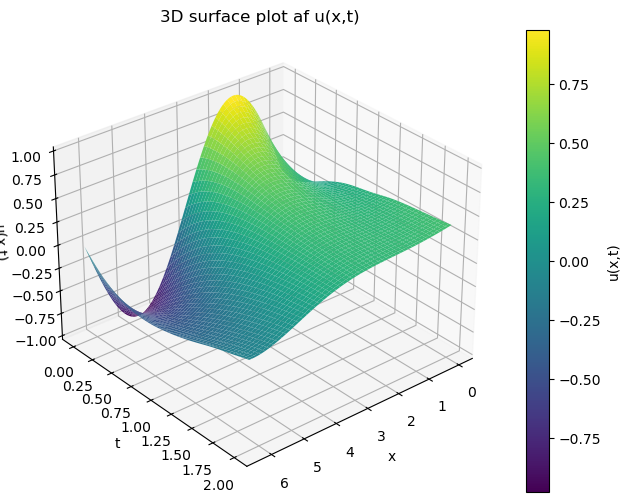

In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Antag at modellen er trænet

# Grid i x
N_x = 200
N_t = 200 
x = np.linspace(0, 2*np.pi, N_x)
t = np.linspace(0, 2, N_t)

# Lav 2D-grid
x_grid, t_grid = np.meshgrid(x, t)

# Flatten gridet og lav det til PyTorch tensors
x_tensor = torch.tensor(
    x_grid.reshape(-1, 1),
    dtype=torch.float32,
    device=device
)

t_tensor = torch.tensor(
    t_grid.reshape(-1, 1),
    dtype=torch.float32,
    device=device
)

# Evaluer MoE i alle punkter
with torch.no_grad():
    _, _, u_pred = MoE(x_tensor, t_tensor)

# Lav output tilbage til 2D grid
U = u_pred.detach().cpu().numpy().reshape(N_t, N_x)
# 3D plot
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(x_grid, t_grid, U, cmap="viridis")

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")
ax.set_title("3D surface plot af u(x,t)")
ax.view_init(elev=30, azim=50)

fig.colorbar(surf, ax=ax, label="u(x,t)")

plt.show()

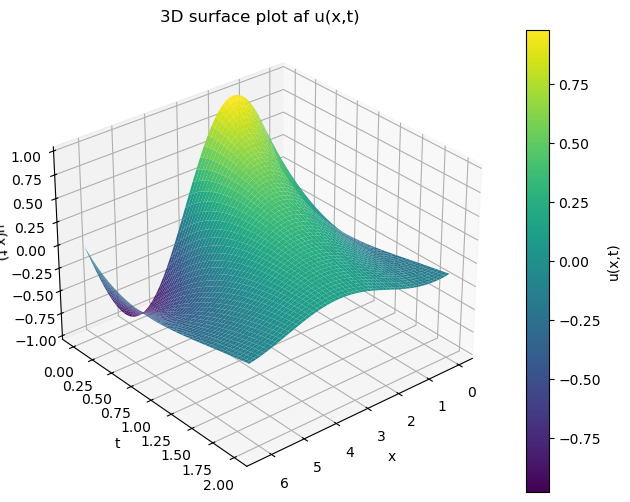

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Parametre (samme som din PDE)
c = 1.0
nu = 1

# Rum
N_x = 200
x = np.linspace(0, 2*np.pi, N_x)

# Tid
N_t = 200
t = np.linspace(0, 2, N_t)

x_grid, t_grid = np.meshgrid(x,t)

# Lav output tilbage til 2D grid
U = np.exp(-nu*t_grid)*np.sin(x_grid-c*t_grid)
# 3D plot
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(x_grid, t_grid, U, cmap="viridis")

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")
ax.set_title("3D surface plot af u(x,t)")
ax.view_init(elev=30, azim=50)

fig.colorbar(surf, ax=ax, label="u(x,t)")

plt.show()
